#### TESTING WITH LOGISTIC REGRESSION

In [33]:
import pandas as pd
import numpy as np

In [34]:
pathA = r'data\processed\aggregated_setA.csv'
pathB = r'data\processed\aggregated_setB.csv'

dfA = pd.read_csv(pathA)
dfB = pd.read_csv(pathB)

Since baseline models i.e Logistic Regressor and Random Forest cannot handle missing values we've to handle it before hand

In [35]:
dfA.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20336 entries, 0 to 20335
Data columns (total 142 columns):
 #    Column             Non-Null Count  Dtype  
---   ------             --------------  -----  
 0    HR_mean            20335 non-null  float64
 1    HR_std             20330 non-null  float64
 2    HR_max             20335 non-null  float64
 3    HR_min             20335 non-null  float64
 4    HR_count           20336 non-null  int64  
 5    O2Sat_mean         20324 non-null  float64
 6    O2Sat_std          20314 non-null  float64
 7    O2Sat_max          20324 non-null  float64
 8    O2Sat_min          20324 non-null  float64
 9    O2Sat_count        20336 non-null  int64  
 10   Temp_mean          20101 non-null  float64
 11   Temp_std           19861 non-null  float64
 12   Temp_max           20101 non-null  float64
 13   Temp_min           20101 non-null  float64
 14   Temp_count         20336 non-null  int64  
 15   SBP_mean           20078 non-null  float64
 16   SB

In [36]:
pd.set_option('display.max_rows', None)
dfA.isna().sum()

HR_mean                  1
HR_std                   6
HR_max                   1
HR_min                   1
HR_count                 0
O2Sat_mean              12
O2Sat_std               22
O2Sat_max               12
O2Sat_min               12
O2Sat_count              0
Temp_mean              235
Temp_std               475
Temp_max               235
Temp_min               235
Temp_count               0
SBP_mean               258
SBP_std                318
SBP_max                258
SBP_min                258
SBP_count                0
MAP_mean                 2
MAP_std                 10
MAP_max                  2
MAP_min                  2
MAP_count                0
DBP_mean              7384
DBP_std               7563
DBP_max               7384
DBP_min               7384
DBP_count                0
Resp_mean               28
Resp_std                51
Resp_max                28
Resp_min                28
Resp_count               0
BaseExcess_mean       7684
BaseExcess_std        9412
B

In [37]:
to_drop = ['Fibrinogen_mean','Fibrinogen_std','Fibrinogen_max','Fibrinogen_min','Fibrinogen_count','Unit1_first','Unit2_first']
impute_cols = [
    "HR_mean",
    "HR_std",
    "HR_max",
    "HR_min",
    "O2Sat_mean",
    "O2Sat_std",
    "O2Sat_max",
    "O2Sat_min",
    "Temp_mean",
    "Temp_std",
    "Temp_max",
    "Temp_min",
    "SBP_mean",
    "SBP_std",
    "SBP_max",
    "SBP_min",
    "MAP_mean",
    "MAP_std",
    "MAP_max",
    "MAP_min",
    "DBP_mean",
    "DBP_std",
    "DBP_max",
    "DBP_min",
    "Resp_mean",
    "Resp_std",
    "Resp_max",
    "Resp_min",
    "BaseExcess_mean",
    "BaseExcess_std",
    "BaseExcess_max",
    "BaseExcess_min",
    "HCO3_mean",
    "HCO3_std",
    "HCO3_max",
    "HCO3_min",
    "Lactate_mean",
    "Lactate_std",
    "Lactate_max",
    "Lactate_min",
    "Glucose_mean",
    "Glucose_std",
    "Glucose_max",
    "Glucose_min",
    "BUN_mean",
    "BUN_std",
    "BUN_max",
    "BUN_min",
    "Creatinine_mean",
    "Creatinine_std",
    "Creatinine_max",
    "Creatinine_min",
    "Calcium_mean",
    "Calcium_std",
    "Calcium_max",
    "Calcium_min",
    "Chloride_mean",
    "Chloride_std",
    "Chloride_max",
    "Chloride_min",
    "Magnesium_mean",
    "Magnesium_std",
    "Magnesium_max",
    "Magnesium_min",
    "Phosphate_mean",
    "Phosphate_std",
    "Phosphate_max",
    "Phosphate_min",
    "Potassium_mean",
    "Potassium_std",
    "Potassium_max",
    "Potassium_min",
    "Hct_mean",
    "Hct_std",
    "Hct_max",
    "Hct_min",
    "Hgb_mean",
    "Hgb_std",
    "Hgb_max",
    "Hgb_min",
    "WBC_mean",
    "WBC_std",
    "WBC_max",
    "WBC_min",
    "Platelets_mean",
    "Platelets_std",
    "Platelets_max",
    "Platelets_min",
    "PTT_mean",
    "PTT_std",
    "PTT_max",
    "PTT_min",
    "FiO2_mean",
    "FiO2_std",
    "FiO2_max",
    "FiO2_min",
    "pH_mean",
    "pH_std",
    "pH_max",
    "pH_min",
    "PaCO2_mean",
    "PaCO2_std",
    "PaCO2_max",
    "PaCO2_min",
    "HospAdmTime_first"
]

In [41]:
for col in dfA.columns:
    if col in to_drop:
        dfA.drop(columns = [col], inplace = True) 
        dfB.drop(columns = [col], inplace = True) 
    if col in impute_cols:
        dfA[col] = dfA[col].median()
        dfB[col] = dfB[col].median()

In [42]:
dfA.isna().sum()

HR_mean              0
HR_std               0
HR_max               0
HR_min               0
HR_count             0
O2Sat_mean           0
O2Sat_std            0
O2Sat_max            0
O2Sat_min            0
O2Sat_count          0
Temp_mean            0
Temp_std             0
Temp_max             0
Temp_min             0
Temp_count           0
SBP_mean             0
SBP_std              0
SBP_max              0
SBP_min              0
SBP_count            0
MAP_mean             0
MAP_std              0
MAP_max              0
MAP_min              0
MAP_count            0
DBP_mean             0
DBP_std              0
DBP_max              0
DBP_min              0
DBP_count            0
Resp_mean            0
Resp_std             0
Resp_max             0
Resp_min             0
Resp_count           0
BaseExcess_mean      0
BaseExcess_std       0
BaseExcess_max       0
BaseExcess_min       0
BaseExcess_count     0
HCO3_mean            0
HCO3_std             0
HCO3_max             0
HCO3_min   

In [44]:
dfA.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20336 entries, 0 to 20335
Data columns (total 135 columns):
 #    Column             Non-Null Count  Dtype  
---   ------             --------------  -----  
 0    HR_mean            20336 non-null  float64
 1    HR_std             20336 non-null  float64
 2    HR_max             20336 non-null  float64
 3    HR_min             20336 non-null  float64
 4    HR_count           20336 non-null  int64  
 5    O2Sat_mean         20336 non-null  float64
 6    O2Sat_std          20336 non-null  float64
 7    O2Sat_max          20336 non-null  float64
 8    O2Sat_min          20336 non-null  float64
 9    O2Sat_count        20336 non-null  int64  
 10   Temp_mean          20336 non-null  float64
 11   Temp_std           20336 non-null  float64
 12   Temp_max           20336 non-null  float64
 13   Temp_min           20336 non-null  float64
 14   Temp_count         20336 non-null  int64  
 15   SBP_mean           20336 non-null  float64
 16   SB

In [ ]:
target = ["SepsisLabel_max"]
features = [
    "HR_mean",
    "HR_std",
    "HR_max",
    "HR_min",
    "HR_count",
    "O2Sat_mean",
    "O2Sat_std",
    "O2Sat_max",
    "O2Sat_min",
    "O2Sat_count",
    "Temp_mean",
    "Temp_std",
    "Temp_max",
    "Temp_min",
    "Temp_count",
    "SBP_mean",
    "SBP_std",
    "SBP_max",
    "SBP_min",
    "SBP_count",
    "MAP_mean",
    "MAP_std",
    "MAP_max",
    "MAP_min",
    "MAP_count",
    "DBP_mean",
    "DBP_std",
    "DBP_max",
    "DBP_min",
    "DBP_count",
    "Resp_mean",
    "Resp_std",
    "Resp_max",
    "Resp_min",
    "Resp_count",
    "BaseExcess_mean",
    "BaseExcess_std",
    "BaseExcess_max",
    "BaseExcess_min",
    "BaseExcess_count",
    "HCO3_mean",
    "HCO3_std",
    "HCO3_max",
    "HCO3_min",
    "HCO3_count",
    "Lactate_mean",
    "Lactate_std",
    "Lactate_max",
    "Lactate_min",
    "Lactate_count",
    "Glucose_mean",
    "Glucose_std",
    "Glucose_max",
    "Glucose_min",
    "Glucose_count",
    "BUN_mean",
    "BUN_std",
    "BUN_max",
    "BUN_min",
    "BUN_count",
    "Creatinine_mean",
    "Creatinine_std",
    "Creatinine_max",
    "Creatinine_min",
    "Creatinine_count",
    "Calcium_mean",
    "Calcium_std",
    "Calcium_max",
    "Calcium_min",
    "Calcium_count",
    "Chloride_mean",
    "Chloride_std",
    "Chloride_max",
    "Chloride_min",
    "Chloride_count",
    "Magnesium_mean",
    "Magnesium_std",
    "Magnesium_max",
    "Magnesium_min",
    "Magnesium_count",
    "Phosphate_mean",
    "Phosphate_std",
    "Phosphate_max",
    "Phosphate_min",
    "Phosphate_count",
    "Potassium_mean",
    "Potassium_std",
    "Potassium_max",
    "Potassium_min",
    "Potassium_count",
    "Hct_mean",
    "Hct_std",
    "Hct_max",
    "Hct_min",
    "Hct_count",
    "Hgb_mean",
    "Hgb_std",
    "Hgb_max",
    "Hgb_min",
    "Hgb_count",
    "WBC_mean",
    "WBC_std",
    "WBC_max",
    "WBC_min",
    "WBC_count",
    "Platelets_mean",
    "Platelets_std",
    "Platelets_max",
    "Platelets_min",
    "Platelets_count",
    "PTT_mean",
    "PTT_std",
    "PTT_max",
    "PTT_min",
    "PTT_count",
    "FiO2_mean",
    "FiO2_std",
    "FiO2_max",
    "FiO2_min",
    "FiO2_count",
    "pH_mean",
    "pH_std",
    "pH_max",
    "pH_min",
    "pH_count",
    "PaCO2_mean",
    "PaCO2_std",
    "PaCO2_max",
    "PaCO2_min",
    "PaCO2_count",
    "Age_first",
    "Gender_first",
    "HospAdmTime_first",
    "ICULOS_max"
]

OUTLIER DETECTION

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

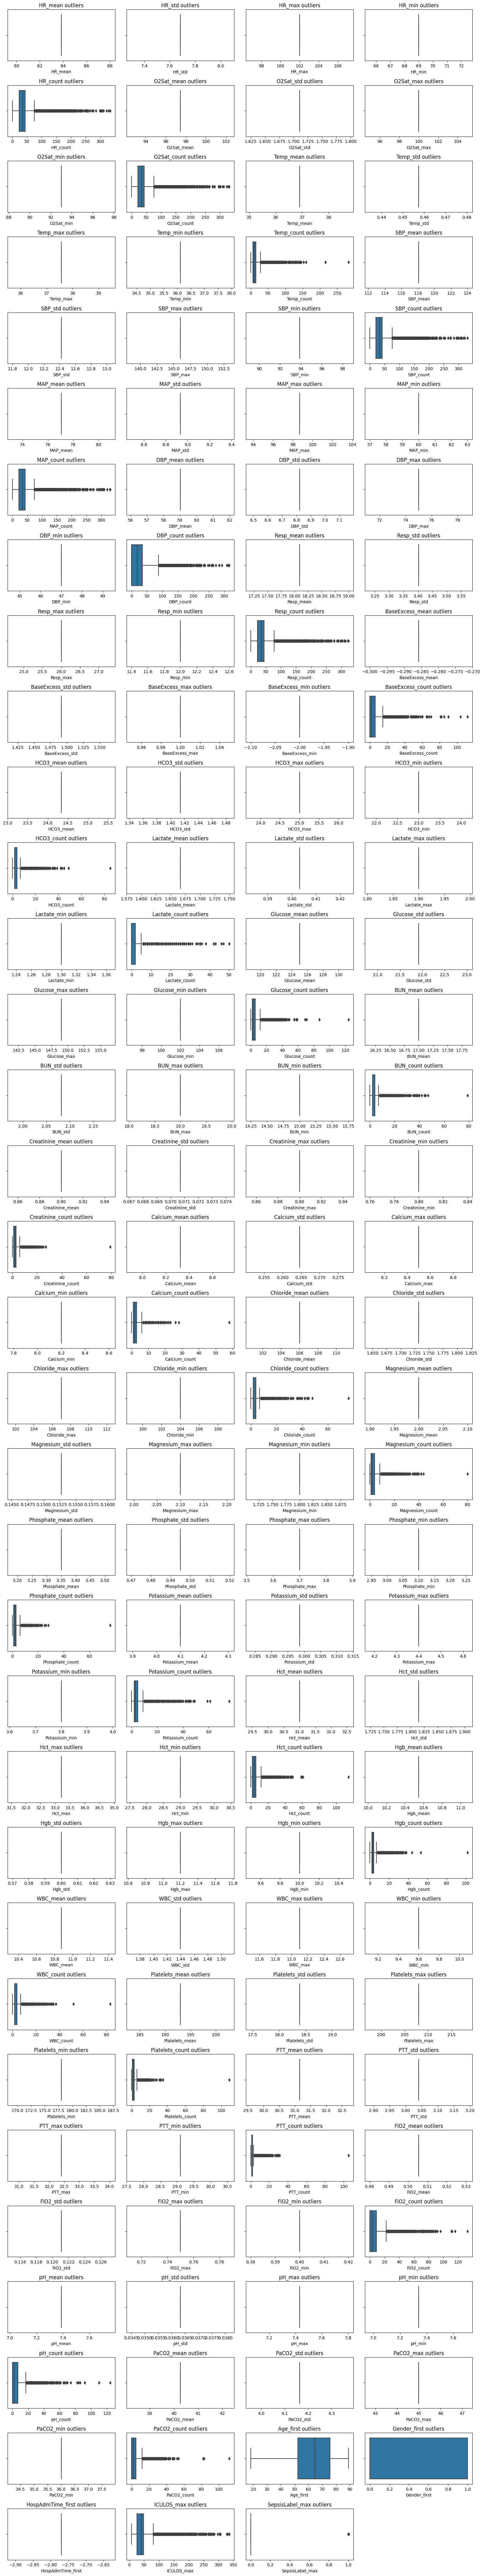

In [50]:
plt.figure(figsize=(16,85))
for i,col in enumerate(dfA.columns,1):
    plt.subplot(34,4,i)
    sns.boxplot(data=dfA, x=col)
    plt.xlabel(col)
    plt.title(f"{col} outliers")
plt.tight_layout()
plt.show()

In logistic regression, a log transform can help for the heavily right-skewed lab features

In [51]:
heavy_skew_cols = [
    "Lactate_mean",
    "Lactate_std",
    "Lactate_max",
    "Lactate_min",
    "Fibrinogen_mean",
    "Fibrinogen_std",
    "Fibrinogen_max",
    "Fibrinogen_min",
    "PTT_mean",
    "PTT_std",
    "PTT_max",
    "PTT_min",
    "FiO2_mean",
    "FiO2_std",
    "FiO2_max",
    "FiO2_min",
    "PaCO2_mean",
    "PaCO2_std",
    "PaCO2_max",
    "PaCO2_min",
    "Creatinine_mean",
    "Creatinine_std",
    "Creatinine_max",
    "Creatinine_min",
    "BUN_mean",
    "BUN_std",
    "BUN_max",
    "BUN_min",
    "Phosphate_mean",
    "Phosphate_std",
    "Phosphate_max",
    "Phosphate_min",
    "Magnesium_mean",
    "Magnesium_std",
    "Magnesium_max",
    "Magnesium_min",
    "Platelets_mean",
    "Platelets_std",
    "Platelets_max",
    "Platelets_min",
    "Glucose_mean",
    "Glucose_std",
    "Glucose_max",
    "Glucose_min",
]

In [52]:
for col in heavy_skew_cols:
    if col in dfA.columns:
        dfA[col] = np.log1p(dfA[col])
    if col in dfB.columns:
        dfB[col] = np.log1p(dfB[col])

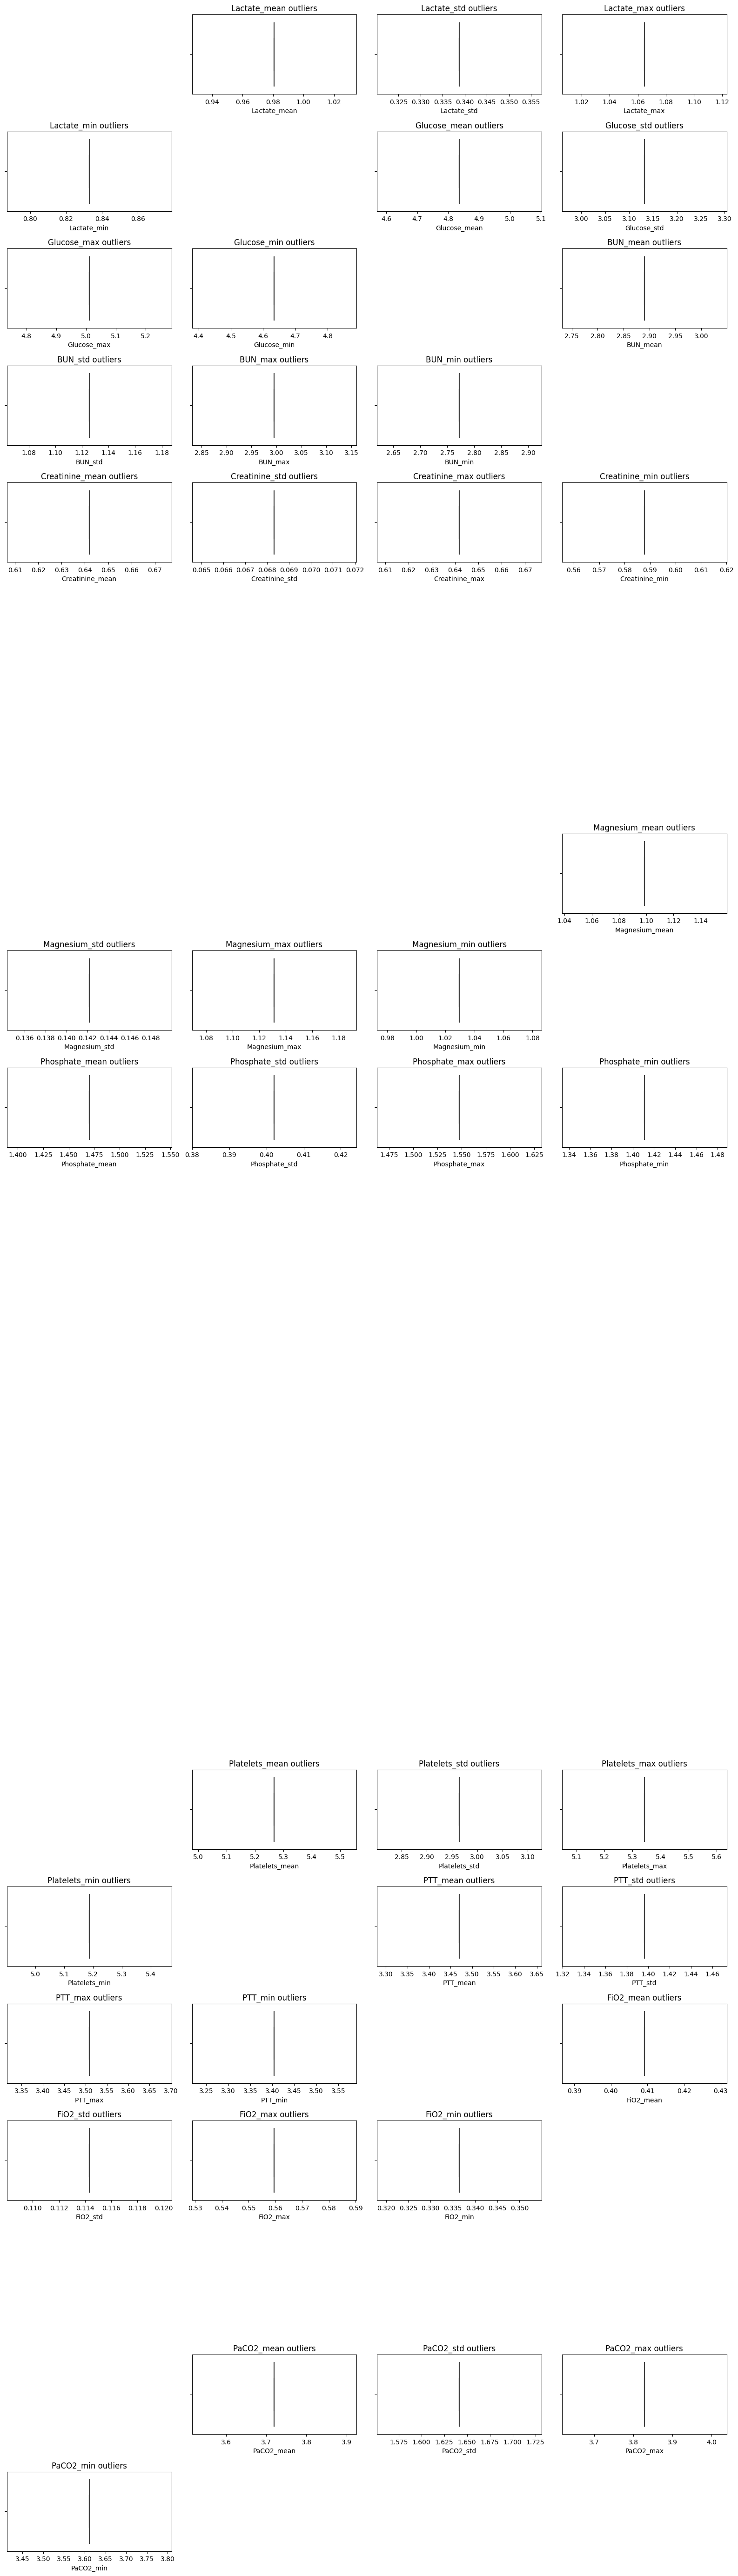

In [54]:
plt.figure(figsize=(16,85))
for i,col in enumerate(dfA.columns,1):
    if col in heavy_skew_cols:
       
       plt.subplot(34,4,i)
       sns.boxplot(data=dfA, x=col)
       plt.xlabel(col)
       plt.title(f"{col} outliers")
plt.tight_layout()
plt.show()